<a href="https://colab.research.google.com/github/nehansa2003/NLP_project/blob/main/Training_DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install -U transformers datasets accelerate scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 9.9 MB/s eta 0:00:00


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available : True
GPU: Tesla T4


In [ ]:
import pandas as pd
import numpy as np
import os
import re
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = '/content/drive/MyDrive/Game_Review_NLP'

train_df = pd.read_csv(
    f'{PROJECT_PATH}/train_reviews_v2.csv'
)

test_df = pd.read_csv(
    f'{PROJECT_PATH}/test_reviews_v2.csv'
)

unseen_df = pd.read_csv(
    f'{PROJECT_PATH}/unseen_reviews_v2.csv'
)

print("Training:", train_df.shape)
print("Testing :", test_df.shape)
print("Unseen  :", unseen_df.shape)

Training: (74665, 19)
Testing : (18900, 19)
Unseen  : (2660, 19)


Verify train/test game separation

In [ ]:
train_game_ids = set(train_df['game_id'].unique())
test_game_ids = set(test_df['game_id'].unique())
unseen_game_ids = set(unseen_df['game_id'].unique())

print("GAME SPLIT")
print("=" * 50)

print("Training games:", len(train_game_ids))
print("Testing games :", len(test_game_ids))
print("Unseen games  :", len(unseen_game_ids))

GAME SPLIT
Training games: 1550
Testing games : 400
Unseen games  : 50


In [ ]:
print("\nGAME LEAKAGE CHECK")
print("=" * 50)

print(
    "Train ∩ Test   :",
    len(train_game_ids & test_game_ids)
)

print(
    "Train ∩ Unseen :",
    len(train_game_ids & unseen_game_ids)
)

print(
    "Test ∩ Unseen  :",
    len(test_game_ids & unseen_game_ids)
)


GAME LEAKAGE CHECK
Train ∩ Test   : 0
Train ∩ Unseen : 0
Test ∩ Unseen  : 0


Prepare labels

In [ ]:
label2id = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

id2label = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

In [ ]:
train_df['label'] = train_df['sentiment_final'].map(label2id)
test_df['label'] = test_df['sentiment_final'].map(label2id)

print(train_df[['sentiment_final', 'label']].drop_duplicates())

     sentiment_final  label
0           positive      2
234          neutral      1
3039        negative      0


In [ ]:
print("Missing training labels:", train_df['label'].isna().sum())
print("Missing testing labels :", test_df['label'].isna().sum())

Missing training labels: 0
Missing testing labels : 0


Analyze class imbalance

In [ ]:
print("TRAINING CLASS DISTRIBUTION")
print("=" * 50)

print(
    train_df['sentiment_final'].value_counts()
)

TRAINING CLASS DISTRIBUTION
sentiment_final
positive    66274
neutral      8037
negative      354
Name: count, dtype: int64


In [ ]:
print("\nTRAINING CLASS PERCENTAGES")
print("=" * 50)

train_distribution = (
    train_df['sentiment_final']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(train_distribution)


TRAINING CLASS PERCENTAGES


,proportion
sentiment_final,
positive,88.76
neutral,10.76
negative,0.47


Load DistilBERT tokenizer

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = 'distilbert/distilbert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("✓ Tokenizer loaded.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✓ Tokenizer loaded.


Tokenize reviews

In [ ]:
train_df = train_df.dropna(
    subset=['review_text', 'label']
).copy()

test_df = test_df.dropna(
    subset=['review_text', 'label']
).copy()

train_df['review_text'] = (
    train_df['review_text']
    .astype(str)
)

test_df['review_text'] = (
    test_df['review_text']
    .astype(str)
)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[['review_text', 'label']],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[['review_text', 'label']],
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['review_text', 'label'],
    num_rows: 74665
})
Dataset({
    features: ['review_text', 'label'],
    num_rows: 18900
})


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples['review_text'],
        truncation=True,
        max_length=512
    )

In [ ]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['review_text']
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['review_text']
)

Map:   0%|          | 0/74665 [00:00<?, ? examples/s]

Map:   0%|          | 0/18900 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_train)
print(tokenized_test)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 74665
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18900
})


Create weighted loss

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label'].values
)

print("Class weights:")
for class_id, weight in zip(classes, class_weights):
    print(
        f"{id2label[class_id]:10s}: {weight:.4f}"
    )

Class weights:
negative  : 70.3060
neutral   : 3.0967
positive  : 0.3755


In [ ]:
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float
)

print(class_weights_tensor)

tensor([70.3060,  3.0967,  0.3755])


Fine-tune DistilBERT

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("✓ DistilBERT loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ DistilBERT loaded.


weighted Trainer


In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_function = torch.nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device)
        )

        loss = loss_function(
            logits,
            labels
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions,
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average='macro',
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        'accuracy': accuracy,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1
    }

dynamic padding

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Training configuration

In [ ]:
from transformers import TrainingArguments

OUTPUT_DIR = f'{PROJECT_PATH}/distilbert_game_sentiment'

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    num_train_epochs=2,

    weight_decay=0.01,

    eval_strategy='epoch',
    save_strategy='epoch',

    load_best_model_at_end=True,

    metric_for_best_model='macro_f1',
    greater_is_better=True,

    logging_steps=100,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to='none',

    seed=42
)

In [ ]:
trainer = WeightedTrainer(
    model=model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_test,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [ ]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.154012,0.565076,0.871587,0.457810,0.486925,0.470105


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.154012,0.565076,0.871587,0.457810,0.486925,0.470105
2,1.007826,0.595212,0.866720,0.522357,0.513325,0.506056


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluate on test games

In [ ]:
evaluation_results = trainer.evaluate()

print("\nDISTILBERT TEST RESULTS")
print("=" * 60)

for key, value in evaluation_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
1.007826,0.595212,2,0.866720,0.522357,0.513325,0.506056



DISTILBERT TEST RESULTS
eval_loss: 0.5952
eval_accuracy: 0.8667
eval_macro_precision: 0.5224
eval_macro_recall: 0.5133
eval_macro_f1: 0.5061


Classification report

In [ ]:
predictions = trainer.predict(
    tokenized_test
)

In [ ]:
y_pred_distilbert = np.argmax(
    predictions.predictions,
    axis=1
)

y_true_distilbert = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print("DISTILBERT CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true_distilbert,
        y_pred_distilbert,
        target_names=[
            'negative',
            'neutral',
            'positive'
        ],
        digits=4,
        zero_division=0
    )
)

DISTILBERT CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.2069    0.0833    0.1188        72
     neutral     0.4175    0.5475    0.4738      2053
    positive     0.9426    0.9092    0.9256     16775

    accuracy                         0.8667     18900
   macro avg     0.5224    0.5133    0.5061     18900
weighted avg     0.8828    0.8667    0.8734     18900



Metrics

In [ ]:
distilbert_accuracy = accuracy_score(
    y_true_distilbert,
    y_pred_distilbert
)

distilbert_precision, distilbert_recall, distilbert_f1, _ = (
    precision_recall_fscore_support(
        y_true_distilbert,
        y_pred_distilbert,
        average='macro',
        zero_division=0
    )
)

print("DISTILBERT RESULTS")
print("=" * 60)

print(
    f"Accuracy       : {distilbert_accuracy:.4f}"
)

print(
    f"Macro Precision: {distilbert_precision:.4f}"
)

print(
    f"Macro Recall   : {distilbert_recall:.4f}"
)

print(
    f"Macro F1       : {distilbert_f1:.4f}"
)

DISTILBERT RESULTS
Accuracy       : 0.8667
Macro Precision: 0.5224
Macro Recall   : 0.5133
Macro F1       : 0.5061


Inspect the negative class

In [ ]:
print("NEGATIVE CLASS PERFORMANCE")
print("=" * 60)

print(
    classification_report(
        y_true_distilbert,
        y_pred_distilbert,
        labels=[0],
        target_names=['negative'],
        digits=4,
        zero_division=0
    )
)

NEGATIVE CLASS PERFORMANCE
              precision    recall  f1-score   support

    negative     0.2069    0.0833    0.1188        72

   micro avg     0.2069    0.0833    0.1188        72
   macro avg     0.2069    0.0833    0.1188        72
weighted avg     0.2069    0.0833    0.1188        72



Confusion matrix

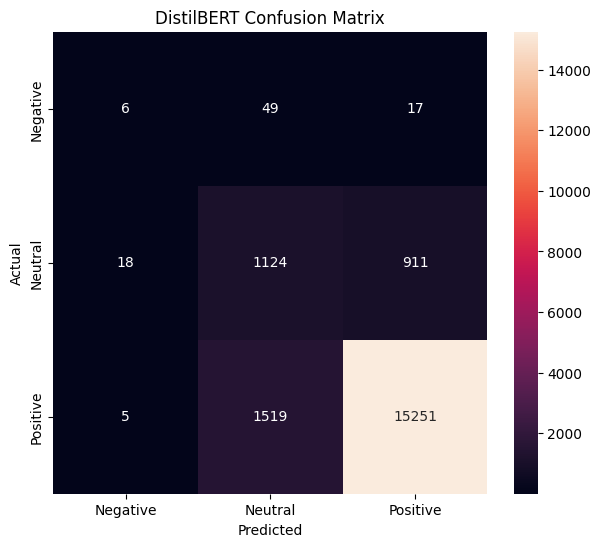

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_distilbert = confusion_matrix(
    y_true_distilbert,
    y_pred_distilbert,
    labels=[0, 1, 2]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt='d',
    xticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    yticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DistilBERT Confusion Matrix')

plt.show()

Comparison

In [ ]:
model_comparison = pd.DataFrame({

    'Model': [
        'Balanced Logistic Regression',
        'Balanced Linear SVM',
        'DistilBERT'
    ],

    'Accuracy': [
        0.8199,
        0.8798,
        distilbert_accuracy
    ],

    'Macro Precision': [
        0.4480,
        0.4503,
        distilbert_precision
    ],

    'Macro Recall': [
        0.4796,
        0.4169,
        distilbert_recall
    ],

    'Macro F1': [
        0.4430,
        0.4290,
        distilbert_f1
    ]
})

display(
    model_comparison.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}'
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Balanced Logistic Regression,0.8199,0.4480,0.4796,0.4430
1,Balanced Linear SVM,0.8798,0.4503,0.4169,0.4290
2,DistilBERT,0.8667,0.5224,0.5133,0.5061


In [ ]:
percentage_comparison = model_comparison.copy()

for column in [
    'Accuracy',
    'Macro Precision',
    'Macro Recall',
    'Macro F1'
]:
    percentage_comparison[column] = (
        percentage_comparison[column] * 100
    ).round(2)

display(percentage_comparison)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Balanced Logistic Regression,81.99,44.80,47.96,44.30
1,Balanced Linear SVM,87.98,45.03,41.69,42.90
2,DistilBERT,86.67,52.24,51.33,50.61


In [ ]:
if distilbert_f1 >= 0.4430:

    print("✓ DistilBERT is currently the best model.")

    BEST_MODEL_DIR = (
        f'{PROJECT_PATH}/best_game_sentiment_model'
    )

    trainer.save_model(
        BEST_MODEL_DIR
    )

    tokenizer.save_pretrained(
        BEST_MODEL_DIR
    )

    print(
        "Model saved to:",
        BEST_MODEL_DIR
    )

else:

    print(
        "DistilBERT did not beat the current "
        "Logistic Regression Macro F1."
    )

✓ DistilBERT is currently the best model.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/Game_Review_NLP/best_game_sentiment_model


In [ ]:
comparison_path = (
    f'{PROJECT_PATH}/model_comparison.csv'
)

model_comparison.to_csv(
    comparison_path,
    index=False
)

print(
    "Comparison saved:",
    comparison_path
)

Comparison saved: /content/drive/MyDrive/Game_Review_NLP/model_comparison.csv


In [ ]:
test_results = test_df.copy()

test_results['predicted_sentiment'] = [
    id2label[p]
    for p in y_pred_distilbert
]

test_results['prediction_correct'] = (
    test_results['label']
    ==
    y_pred_distilbert
)

test_results.to_csv(
    f'{PROJECT_PATH}/distilbert_test_predictions.csv',
    index=False
)

print("✓ Test predictions saved.")

✓ Test predictions saved.


Complete report

In [ ]:
print(
    classification_report(
        y_true_distilbert,
        y_pred_distilbert,
        target_names=[
            'negative',
            'neutral',
            'positive'
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.2069    0.0833    0.1188        72
     neutral     0.4175    0.5475    0.4738      2053
    positive     0.9426    0.9092    0.9256     16775

    accuracy                         0.8667     18900
   macro avg     0.5224    0.5133    0.5061     18900
weighted avg     0.8828    0.8667    0.8734     18900



prediction probabilities

In [ ]:
from scipy.special import softmax

logits = predictions.predictions

probabilities = softmax(
    logits,
    axis=1
)

print(probabilities.shape)

(18900, 3)


Inspect negative predictions

In [ ]:
negative_probabilities = probabilities[:, 0]

print(
    "Maximum negative probability:",
    negative_probabilities.max()
)

print(
    "Mean negative probability:",
    negative_probabilities.mean()
)

Maximum negative probability: 0.91626394
Mean negative probability: 0.0036962226


In [ ]:
probability_df = pd.DataFrame({
    'actual': y_true_distilbert,
    'negative_probability': probabilities[:, 0],
    'neutral_probability': probabilities[:, 1],
    'positive_probability': probabilities[:, 2]
})

display(
    probability_df.sort_values(
        'negative_probability',
        ascending=False
    ).head(20)
)

,actual,negative_probability,neutral_probability,positive_probability
10287,1,0.916264,0.053229,0.030507
10427,2,0.892406,0.077560,0.030034
17897,0,0.825640,0.146108,0.028252
17675,1,0.818790,0.148423,0.032788
18371,0,0.790641,0.177637,0.031722
12578,0,0.762459,0.203414,0.034127
17889,1,0.758609,0.210414,0.030977
12869,1,0.741210,0.226319,0.032471
15847,1,0.736152,0.230963,0.032886
14599,0,0.726133,0.239673,0.034195


In [ ]:
def apply_negative_threshold(probabilities, negative_threshold):

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    negative_mask = (
        probabilities[:, 0]
        >= negative_threshold
    )

    predictions[negative_mask] = 0

    return predictions

In [ ]:
thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in thresholds:

    preds = apply_negative_threshold(
        probabilities,
        threshold
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true_distilbert,
            preds,
            average=None,
            labels=[0, 1, 2],
            zero_division=0
        )
    )

    macro_f1 = f1_score(
        y_true_distilbert,
        preds,
        average='macro',
        zero_division=0
    )

    accuracy = accuracy_score(
        y_true_distilbert,
        preds
    )

    threshold_results.append({
        'Negative Threshold': threshold,
        'Accuracy': accuracy,
        'Negative Precision': precision[0],
        'Negative Recall': recall[0],
        'Negative F1': f1[0],
        'Neutral F1': f1[1],
        'Positive F1': f1[2],
        'Macro F1': macro_f1
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_results_df.style.format({
        'Accuracy': '{:.4f}',
        'Negative Precision': '{:.4f}',
        'Negative Recall': '{:.4f}',
        'Negative F1': '{:.4f}',
        'Neutral F1': '{:.4f}',
        'Positive F1': '{:.4f}',
        'Macro F1': '{:.4f}'
    })
)

,Negative Threshold,Accuracy,Negative Precision,Negative Recall,Negative F1,Neutral F1,Positive F1,Macro F1
0,0.200000,0.8662,0.2373,0.1944,0.2137,0.4696,0.9256,0.5363
1,0.250000,0.8666,0.2745,0.1944,0.2276,0.4717,0.9256,0.5417
2,0.300000,0.8668,0.3043,0.1944,0.2373,0.4725,0.9256,0.5451
3,0.350000,0.8669,0.3171,0.1806,0.2301,0.4733,0.9256,0.5430
4,0.400000,0.8667,0.2188,0.0972,0.1346,0.4732,0.9256,0.5111
5,0.450000,0.8667,0.2069,0.0833,0.1188,0.4738,0.9256,0.5061
6,0.500000,0.8667,0.2069,0.0833,0.1188,0.4738,0.9256,0.5061


Freeze the threshold

In [50]:
BEST_NEGATIVE_THRESHOLD = 0.30

print(
    "Final negative threshold:",
    BEST_NEGATIVE_THRESHOLD
)

Final negative threshold: 0.3


Finale prediction function


In [51]:
def predict_with_threshold(probabilities, threshold=0.30):

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    negative_mask = (
        probabilities[:, 0] >= threshold
    )

    predictions[negative_mask] = 0

    return predictions

In [52]:
y_pred_threshold = predict_with_threshold(
    probabilities,
    BEST_NEGATIVE_THRESHOLD
)

In [53]:
print(
    classification_report(
        y_true_distilbert,
        y_pred_threshold,
        target_names=[
            'negative',
            'neutral',
            'positive'
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.3043    0.1944    0.2373        72
     neutral     0.4176    0.5441    0.4725      2053
    positive     0.9426    0.9092    0.9256     16775

    accuracy                         0.8668     18900
   macro avg     0.5549    0.5492    0.5451     18900
weighted avg     0.8832    0.8668    0.8738     18900



Save the final model

In [54]:
FINAL_MODEL_DIR = (
    f'{PROJECT_PATH}/final_distilbert_game_sentiment'
)

trainer.save_model(
    FINAL_MODEL_DIR
)

tokenizer.save_pretrained(
    FINAL_MODEL_DIR
)

print(
    "✓ Final model saved to:",
    FINAL_MODEL_DIR
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Final model saved to: /content/drive/MyDrive/Game_Review_NLP/final_distilbert_game_sentiment


In [55]:
import json

threshold_config = {
    "model": "DistilBERT",
    "negative_threshold": 0.30,
    "labels": {
        "0": "negative",
        "1": "neutral",
        "2": "positive"
    }
}

with open(
    f'{FINAL_MODEL_DIR}/threshold_config.json',
    'w'
) as f:

    json.dump(
        threshold_config,
        f,
        indent=4
    )

print("✓ Threshold configuration saved.")

✓ Threshold configuration saved.
